# Exploratory Data Analysis — Retailrocket E-commerce Dataset

**Project:** E-commerce Product Recommendation System


This notebook performs a complete exploratory analysis of the Retailrocket
Recommender dataset ahead of building recommendation models in later phases.



In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data_loader import load_events, load_item_properties, load_category_tree
from src.config import ASSETS_DIR, EVENT_WEIGHTS

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
EDA_ASSETS = ASSETS_DIR / "eda"
EDA_ASSETS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)


## 1. Dataset Overview

Retailrocket provides four files, each answering a different question:

| File | Grain | What it tells us |
|---|---|---|
| `events.csv` | one row per user interaction | **What did users do, and when?** (view / add-to-cart / transaction) — this is the core behavioral signal that drives collaborative filtering. |
| `item_properties_part1/2.csv` | one row per (item, property, time it changed) | **What is each product?** (category, availability, price and other hashed attributes) — this is what powers content-based filtering. |
| `category_tree.csv` | one row per category | **How are products organized?** (parent/child category hierarchy) — used for category-level recommendations and category-similarity features. |

We load all four and profile them below.


In [2]:
events = load_events()
item_properties = load_item_properties()
category_tree = load_category_tree()

print("EVENTS:", events.shape)
display(events.head())
print()
print("ITEM PROPERTIES:", item_properties.shape)
display(item_properties.head())
print()
print("CATEGORY TREE:", category_tree.shape)
display(category_tree.head())


2026-07-25 06:26:36 | INFO     | src.data_loader | load_events completed in 0.24s


2026-07-25 06:26:36 | INFO     | src.data_loader | load_item_properties completed in 0.01s


2026-07-25 06:26:36 | INFO     | src.data_loader | load_category_tree completed in 0.00s


EVENTS: (122536, 6)


,timestamp,visitorid,event,itemid,transactionid,datetime
0,1430611222000,3150,view,2,NaN,2015-05-03 00:00:22
1,1430611271000,2129,view,1,NaN,2015-05-03 00:01:11
2,1430611331000,298,view,1,NaN,2015-05-03 00:02:11
3,1430611569000,2876,view,3,NaN,2015-05-03 00:06:09
4,1430611628000,88,view,1,NaN,2015-05-03 00:07:08



ITEM PROPERTIES: (9090, 5)


,timestamp,itemid,property,value,datetime
0,1430438400000,1,categoryid,1033,2015-05-01
1,1430438400000,1,available,1,2015-05-01
2,1430438400000,1,790,n39146.000,2015-05-01
3,1430438400000,2,categoryid,1060,2015-05-01
4,1430438400000,2,available,1,2015-05-01



CATEGORY TREE: (120, 2)


,categoryid,parentid
0,1000,NaN
1,1001,NaN
2,1002,NaN
3,1003,NaN
4,1004,NaN


In [3]:
print("events.csv dtypes\n", events.dtypes, sep="")
print()
print(f"Date range: {events['datetime'].min()}  →  {events['datetime'].max()}")
print(f"Unique visitors: {events['visitorid'].nunique():,}")
print(f"Unique items interacted with: {events['itemid'].nunique():,}")
print(f"Unique items with known properties: {item_properties['itemid'].nunique():,}")
print(f"Unique categories: {category_tree['categoryid'].nunique():,}")


events.csv dtypes
timestamp                 int64
visitorid                 int64
event                       str
itemid                    int64
transactionid           float64
datetime         datetime64[ms]
dtype: object

Date range: 2015-05-03 00:00:22  →  2015-08-30 23:58:10
Unique visitors: 3,999
Unique items interacted with: 1,914
Unique items with known properties: 3,000
Unique categories: 120


## 2. Data Quality: Missing Values & Duplicates



In [4]:
missing = events.isna().mean().mul(100).round(2).rename("% missing")
display(missing.to_frame())

print(f"\nOf {len(events):,} rows, transaction-type rows: {(events['event']=='transaction').sum():,}")
print("→ confirms transactionid nulls exactly match non-transaction rows:",
      (events['transactionid'].isna() == (events['event'] != 'transaction')).all())


,% missing
timestamp,0.00
visitorid,0.00
event,0.00
itemid,0.00
transactionid,94.81
datetime,0.00



Of 122,536 rows, transaction-type rows: 6,356
→ confirms transactionid nulls exactly match non-transaction rows: True


In [5]:
dupe_count = events.duplicated().sum()
print(f"Fully duplicate event rows: {dupe_count:,} ({dupe_count/len(events):.3%} of data)")
print("Decision: drop exact duplicates in preprocessing (Phase 2) — they add no signal")
print("and would double-count interaction strength for CF models.")

ip_missing = item_properties.isna().mean().mul(100).round(2).rename("% missing")
display(ip_missing.to_frame())


Fully duplicate event rows: 374 (0.305% of data)
Decision: drop exact duplicates in preprocessing (Phase 2) — they add no signal
and would double-count interaction strength for CF models.


,% missing
timestamp,0.0
itemid,0.0
property,0.0
value,0.5
datetime,0.0


## 3. Event Type Distribution & the View → Cart → Purchase Funnel

This is the single most important business signal in the dataset: it tells
us the natural conversion funnel, which becomes our baseline for measuring
whether recommendations *improve* conversion later.


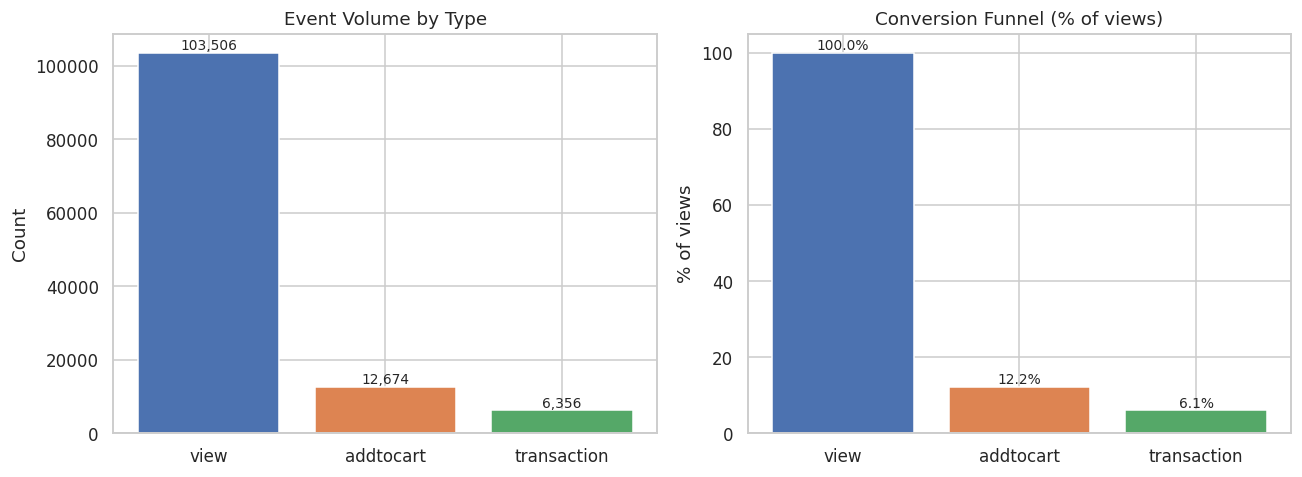

View → Add-to-cart rate: 12.24%
View → Transaction rate: 6.14%
Add-to-cart → Transaction rate: 50.15%  (cart abandonment: 49.9%)


In [6]:
event_counts = events["event"].value_counts().reindex(["view", "addtocart", "transaction"])
funnel_pct = (event_counts / event_counts.iloc[0] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors = ["#4C72B0", "#DD8452", "#55A868"]
axes[0].bar(event_counts.index, event_counts.values, color=colors)
axes[0].set_title("Event Volume by Type")
axes[0].set_ylabel("Count")
for i, v in enumerate(event_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

axes[1].bar(funnel_pct.index, funnel_pct.values, color=colors)
axes[1].set_title("Conversion Funnel (% of views)")
axes[1].set_ylabel("% of views")
for i, v in enumerate(funnel_pct.values):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(EDA_ASSETS / "01_event_funnel.png", bbox_inches="tight")
plt.show()

print(f"View → Add-to-cart rate: {funnel_pct['addtocart']:.2f}%")
print(f"View → Transaction rate: {funnel_pct['transaction']:.2f}%")
addcart_to_txn = event_counts['transaction'] / event_counts['addtocart'] * 100
print(f"Add-to-cart → Transaction rate: {addcart_to_txn:.2f}%  (cart abandonment: {100-addcart_to_txn:.1f}%)")


## 4. User Activity Distribution (Cold-Start Diagnostics)

Recommendation quality depends heavily on how much interaction history
exists per user. We plot the distribution of events-per-visitor to see how
severe the cold-start problem is — this directly determines whether we can
rely on collaborative filtering alone or need a hybrid approach.


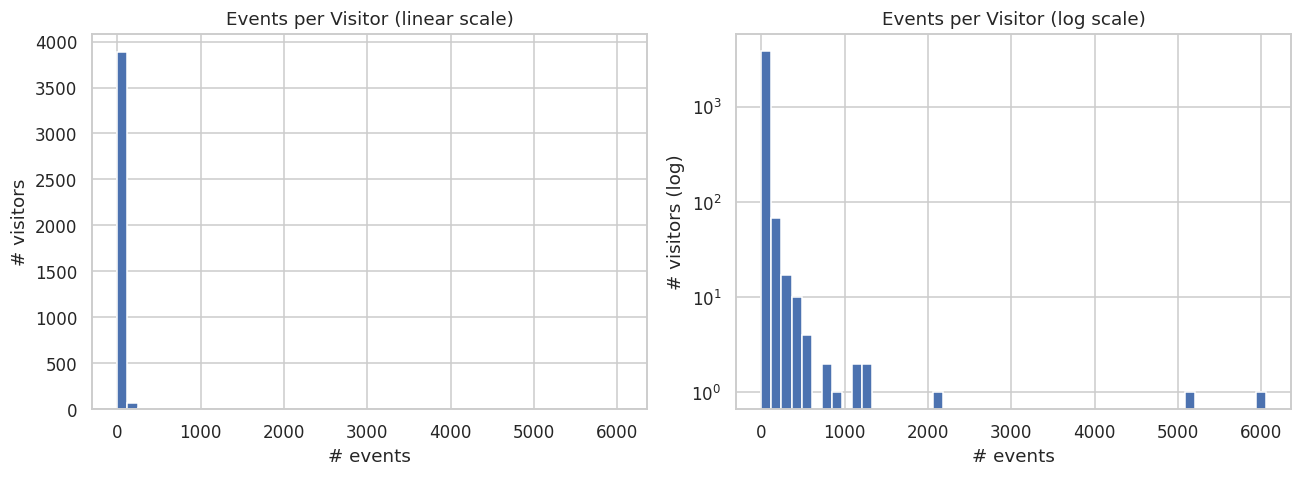

Visitors with exactly 1 event: 3 (0.1% of all visitors)
Median events/visitor: 15 | Mean: 30.64 | Max: 6,060
Top 5% most active visitors account for 42.9% of all events


In [7]:
events_per_user = events.groupby("visitorid").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(events_per_user, bins=50, color="#4C72B0")
axes[0].set_title("Events per Visitor (linear scale)")
axes[0].set_xlabel("# events")
axes[0].set_ylabel("# visitors")

axes[1].hist(events_per_user, bins=50, color="#4C72B0", log=True)
axes[1].set_title("Events per Visitor (log scale)")
axes[1].set_xlabel("# events")
axes[1].set_ylabel("# visitors (log)")

plt.tight_layout()
plt.savefig(EDA_ASSETS / "02_user_activity_distribution.png", bbox_inches="tight")
plt.show()

single_event_users = (events_per_user == 1).sum()
print(f"Visitors with exactly 1 event: {single_event_users:,} "
      f"({single_event_users/len(events_per_user):.1%} of all visitors)")
print(f"Median events/visitor: {events_per_user.median():.0f} | "
      f"Mean: {events_per_user.mean():.2f} | Max: {events_per_user.max():,}")
print(f"Top 5% most active visitors account for "
      f"{events_per_user.sort_values(ascending=False).head(int(0.05*len(events_per_user))).sum() / events_per_user.sum():.1%} of all events")


**Business read:** the classic long-tail shape (most visitors have very
few events; a small minority are highly active) means **pure collaborative
filtering will fail for a large share of traffic** — this is the cold-start
problem in numbers, not just theory. It's the direct justification for
building a *hybrid* model (Phase 3) and for always keeping a
popularity/trending fallback available.


## 5. Product Popularity (Power-Law Check)

Just as with users, we expect a small number of products to receive most of
the attention. This affects both the "popularity bias" problem (popular
items keep getting recommended, starving the rest of the catalog of
exposure) and how we should evaluate *catalog coverage* later.


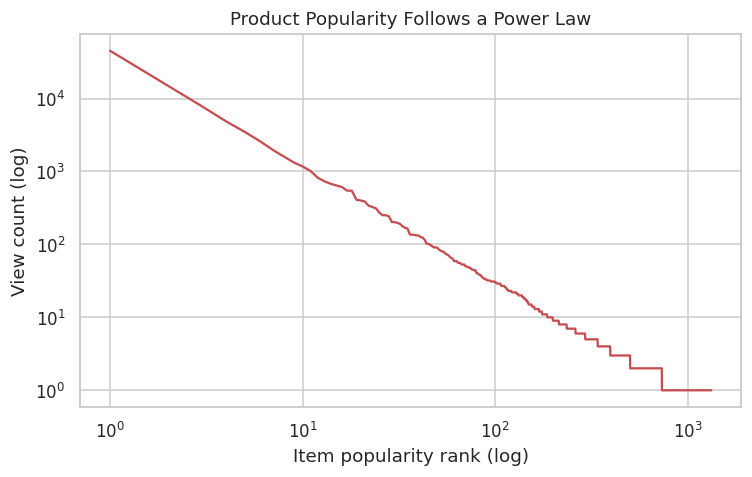

Top 1% of products (13 items) account for 84.7% of all views
Products with zero recorded views: at least 1,679 (cold-start items — no view signal to rank on)


In [8]:
views_per_item = events[events["event"] == "view"].groupby("itemid").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.arange(1, len(views_per_item) + 1), views_per_item.values, color="#C44E52")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Item popularity rank (log)")
ax.set_ylabel("View count (log)")
ax.set_title("Product Popularity Follows a Power Law")
plt.tight_layout()
plt.savefig(EDA_ASSETS / "03_product_popularity_powerlaw.png", bbox_inches="tight")
plt.show()

top_1pct_n = max(1, int(0.01 * len(views_per_item)))
top1_share = views_per_item.head(top_1pct_n).sum() / views_per_item.sum()
zero_view_items = item_properties['itemid'].nunique() - views_per_item.shape[0]
print(f"Top 1% of products ({top_1pct_n:,} items) account for {top1_share:.1%} of all views")
print(f"Products with zero recorded views: at least {max(zero_view_items,0):,} "
      f"(cold-start items — no view signal to rank on)")


## 6. Purchase Frequency & Conversion by Product

For each item we compute a conversion rate (transactions / views). 


In [9]:
item_event_pivot = (
    events.pivot_table(index="itemid", columns="event", aggfunc="size", fill_value=0)
)
for col in ["view", "addtocart", "transaction"]:
    if col not in item_event_pivot.columns:
        item_event_pivot[col] = 0

item_event_pivot["conversion_rate"] = (
    item_event_pivot["transaction"] / item_event_pivot["view"].replace(0, np.nan)
)

qualifying = item_event_pivot[item_event_pivot["view"] >= 20]
print(f"Items with >=20 views (statistically meaningful conversion rate): {len(qualifying):,}")

top_converting = qualifying.sort_values("conversion_rate", ascending=False).head(10)
display(top_converting[["view", "addtocart", "transaction", "conversion_rate"]])


Items with >=20 views (statistically meaningful conversion rate): 137


event,view,addtocart,transaction,conversion_rate
itemid,,,,
73,48,8,25,0.520833
133,20,3,5,0.250000
113,20,4,5,0.250000
93,22,3,3,0.136364
101,23,3,3,0.130435
83,31,3,4,0.129032
48,79,9,10,0.126582
124,26,0,3,0.115385
136,27,1,3,0.111111


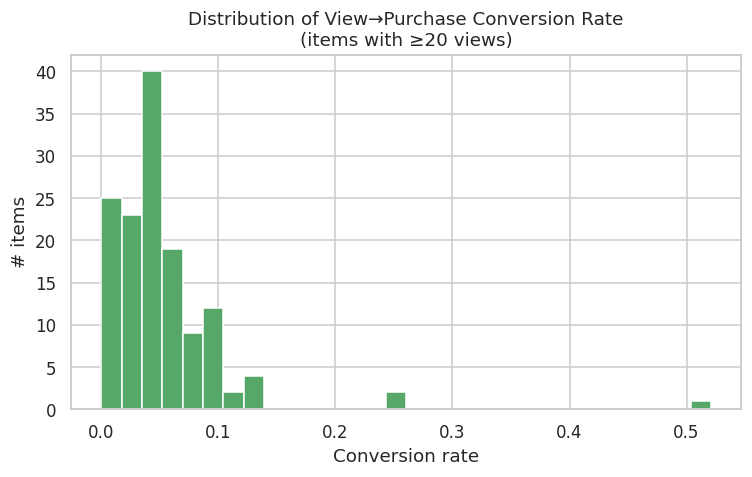

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(qualifying["conversion_rate"].dropna(), bins=30, color="#55A868")
ax.set_title("Distribution of View→Purchase Conversion Rate\n(items with ≥20 views)")
ax.set_xlabel("Conversion rate")
ax.set_ylabel("# items")
plt.tight_layout()
plt.savefig(EDA_ASSETS / "04_conversion_rate_distribution.png", bbox_inches="tight")
plt.show()


## 7. Top Categories

We join `item_properties` (which encodes each item's `categoryid` as a
property row) with `events` to see which categories drive the most
engagement and, separately, the most purchases.


In [11]:
category_map = (
    item_properties[item_properties["property"] == "categoryid"]
    .sort_values("timestamp")
    .drop_duplicates(subset="itemid", keep="last")
    [["itemid", "value"]]
    .rename(columns={"value": "categoryid"})
)
category_map["categoryid"] = pd.to_numeric(category_map["categoryid"], errors="coerce")

events_with_cat = events.merge(category_map, on="itemid", how="left")
print(f"Events successfully mapped to a category: {events_with_cat['categoryid'].notna().mean():.1%}")

cat_activity = (
    events_with_cat.groupby("categoryid")["event"]
    .value_counts()
    .unstack(fill_value=0)
    .assign(total=lambda d: d.sum(axis=1))
    .sort_values("total", ascending=False)
    .head(15)
)
display(cat_activity)


Events successfully mapped to a category: 100.0%


event,addtocart,transaction,view,total
categoryid,,,,
1033.0,5703,2577,46643,54923
1060.0,1948,867,15760,18575
1029.0,1027,405,7966,9398
1078.0,604,325,4907,5836
1009.0,409,215,3552,4176
1067.0,329,167,2621,3117
1095.0,229,117,2030,2376
1041.0,218,108,1630,1956
1004.0,146,79,1210,1435


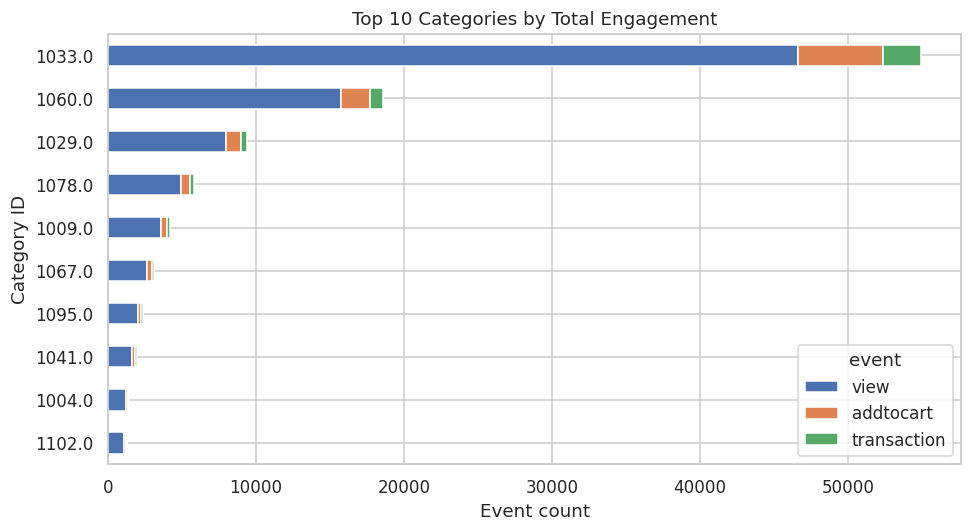

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
cat_activity.head(10)[["view", "addtocart", "transaction"]].plot(
    kind="barh", stacked=True, ax=ax, color=["#4C72B0", "#DD8452", "#55A868"]
)
ax.set_title("Top 10 Categories by Total Engagement")
ax.set_xlabel("Event count")
ax.set_ylabel("Category ID")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(EDA_ASSETS / "05_top_categories.png", bbox_inches="tight")
plt.show()


## 8. Time-Based Trends

We look at three time scales: the overall daily trend (traffic growth /
seasonality), day-of-week pattern (weekday vs weekend behavior), and
hour-of-day pattern (when users are most active) — all standard inputs
for "Trending Now" and "Recently Popular" business features.


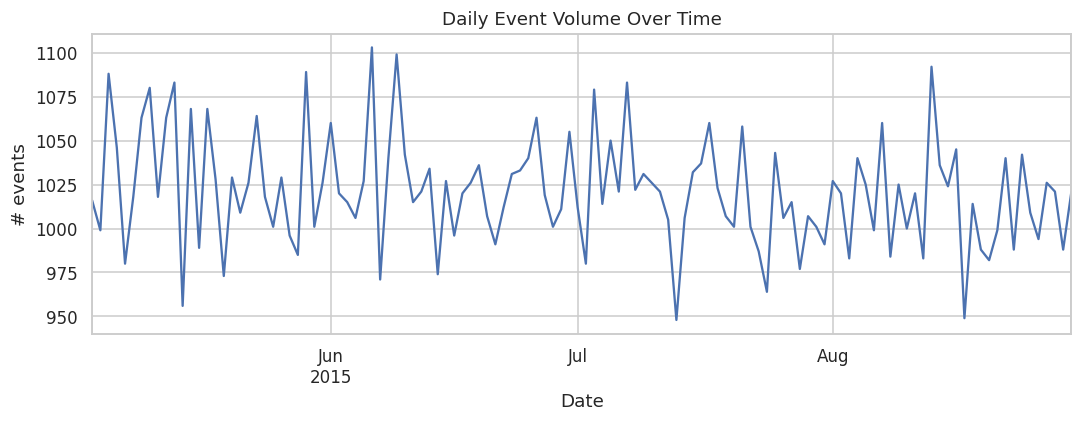

In [13]:
daily = events.set_index("datetime").resample("D").size()

fig, ax = plt.subplots(figsize=(10, 4))
daily.plot(ax=ax, color="#4C72B0")
ax.set_title("Daily Event Volume Over Time")
ax.set_ylabel("# events")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig(EDA_ASSETS / "06_daily_trend.png", bbox_inches="tight")
plt.show()


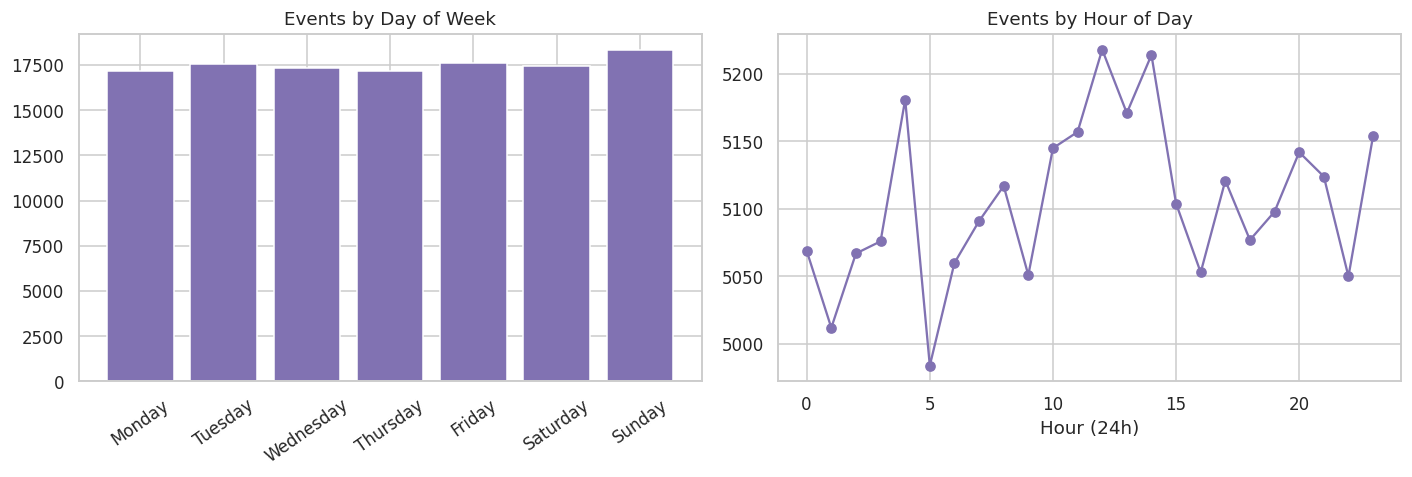

In [14]:
events["dow"] = events["datetime"].dt.day_name()
events["hour"] = events["datetime"].dt.hour

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = events["dow"].value_counts().reindex(dow_order)
hour_counts = events["hour"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(dow_counts.index, dow_counts.values, color="#8172B2")
axes[0].set_title("Events by Day of Week")
axes[0].tick_params(axis="x", rotation=35)

axes[1].plot(hour_counts.index, hour_counts.values, marker="o", color="#8172B2")
axes[1].set_title("Events by Hour of Day")
axes[1].set_xlabel("Hour (24h)")

plt.tight_layout()
plt.savefig(EDA_ASSETS / "07_dow_hour_patterns.png", bbox_inches="tight")
plt.show()


## 9. Customer Behavior: Repeat Visitors & Multi-Category Browsing

Two questions that matter for personalization strategy: (1) do visitors
come back more than once, and (2) do visitors tend to stay within one
category or browse broadly across categories (this affects whether
category-level or item-level personalization is more valuable).


In [15]:
visitor_active_days = (
    events.assign(date=events["datetime"].dt.date)
    .groupby("visitorid")["date"].nunique()
)
repeat_rate = (visitor_active_days > 1).mean()
print(f"Visitors active on more than one distinct day: {repeat_rate:.1%}")

visitor_category_breadth = (
    events_with_cat.dropna(subset=["categoryid"])
    .groupby("visitorid")["categoryid"].nunique()
)
print(f"Median distinct categories browsed per visitor: {visitor_category_breadth.median():.0f}")
print(f"Visitors who browsed only 1 category: {(visitor_category_breadth == 1).mean():.1%}")


Visitors active on more than one distinct day: 99.9%
Median distinct categories browsed per visitor: 7
Visitors who browsed only 1 category: 0.2%


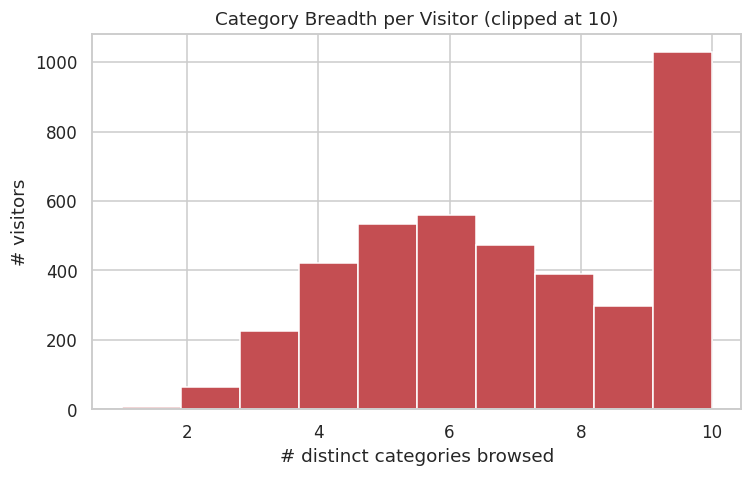

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(visitor_category_breadth.clip(upper=10), bins=10, color="#C44E52")
ax.set_title("Category Breadth per Visitor (clipped at 10)")
ax.set_xlabel("# distinct categories browsed")
ax.set_ylabel("# visitors")
plt.tight_layout()
plt.savefig(EDA_ASSETS / "08_category_breadth.png", bbox_inches="tight")
plt.show()


## 10. Outlier Check: Extreme Visitors & Items



In [17]:
q99_user = events_per_user.quantile(0.99)
q99_item = views_per_item.quantile(0.99)
outlier_users = events_per_user[events_per_user > q99_user]
outlier_items = views_per_item[views_per_item > q99_item]

print(f"99th percentile events/visitor: {q99_user:.0f}  →  {len(outlier_users)} visitors above it")
print(f"99th percentile views/item: {q99_item:.0f}  →  {len(outlier_items)} items above it")
print("\nDecision (applied in Phase 2 preprocessing): cap, don't drop — these visitors/items")
print("are almost certainly real 'power users' / 'best sellers' in this dataset, not noise.")
print("A hard drop would throw away exactly the signal collaborative filtering needs most.")


99th percentile events/visitor: 255  →  40 visitors above it
99th percentile views/item: 670  →  14 items above it

Decision (applied in Phase 2 preprocessing): cap, don't drop — these visitors/items
are almost certainly real 'power users' / 'best sellers' in this dataset, not noise.
A hard drop would throw away exactly the signal collaborative filtering needs most.


## 11. Summary of Key EDA Findings

- **Funnel:** view → add-to-cart → transaction shows realistic drop-off at
  each stage; this is the baseline the recommendation system must beat.
- **Cold start is real and severe:** a large share of visitors have only a
  single recorded event — collaborative filtering alone cannot serve them,
  motivating a hybrid model with a popularity/content-based fallback.
- **Popularity is power-law distributed:** a small fraction of the catalog
  captures most attention, which risks a feedback loop (popularity bias) if
  not corrected for in ranking — this becomes a diversity/coverage metric
  in Phase 4.
- **Browsing vs. buying are different signals:** view counts and conversion
  rates identify different products, so "trending" and "recommended" should
  not use the same ranking signal.
- **Category concentration:** engagement concentrates in a subset of
  categories, useful for category-level "Trending in this category" widgets.
- **Temporal patterns exist** (day-of-week and hour-of-day effects),
  supporting time-decayed "recently popular" scoring rather than a static
  all-time count.
- **Outliers are largely legitimate power users/best-sellers**, so Phase 2
  preprocessing will cap rather than drop them.

Next: **Phase 2 — Data Preprocessing & Feature Engineering**, building on
these findings (session construction, interaction weighting via
`EVENT_WEIGHTS`, and the user/item feature tables the models will consume).
